In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.multiclass import OneVsRestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

## 1. Бинарная классификация

Пусть задана обучающая выборка

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{n},
$$

где

$$
x_i \in \mathbb{R}^m
$$

— вектор признаков объекта, а

$$
y_i \in \{0, 1\}
$$

— метка класса.

Задача бинарной классификации состоит в построении функции

$$
f: \mathbb{R}^m \rightarrow \{0, 1\},
$$

которая по вектору признаков объекта предсказывает один из двух классов.

В логистической регрессии сначала вычисляется линейная комбинация признаков:

$$
z_i = w^T x_i + b,
$$

где

$$
w = (w_1, w_2, \dots, w_m)^T
$$

— вектор весов модели, а

$$
b
$$

— свободный член.

## 2. Сигмоидальная функция

Линейная комбинация признаков

$$
z = w^T x + b
$$

может принимать любые вещественные значения. Для интерпретации результата как вероятности используется сигмоидальная функция:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}.
$$

Значение сигмоиды всегда лежит в интервале:

$$
0 < \sigma(z) < 1.
$$

Поэтому в бинарной логистической регрессии величина

$$
P(y = 1 \mid x) = \sigma(w^T x + b)
$$

интерпретируется как вероятность принадлежности объекта к классу 1.

Соответственно,

$$
P(y = 0 \mid x) = 1 - P(y = 1 \mid x).
$$

Иными словами:

$$
P(y = 0 \mid x) = 1 - \sigma(w^T x + b).
$$

## 3. Правило принятия решения

После вычисления вероятности

$$
\hat{p} = P(y = 1 \mid x)
$$

необходимо перейти от вероятности к метке класса.

Обычно используется порог классификации

$$
t = 0.5.
$$

Тогда правило классификации имеет вид:

$$
\hat{y} =
\begin{cases}
1, & \hat{p} \geq t, \\
0, & \hat{p} < t.
\end{cases}
$$

При стандартном пороге:

$$
\hat{y} =
\begin{cases}
1, & \hat{p} \geq 0.5, \\
0, & \hat{p} < 0.5.
\end{cases}
$$

Однако порог $0.5$ не всегда является оптимальным. Если цена ошибок разных типов различается, порог можно изменять. Например, при необходимости повысить полноту положительного класса порог часто уменьшают.

## 4. Логарифм отношения шансов

Логистическая регрессия имеет важную интерпретацию через отношение шансов.

Вероятность положительного класса:

$$
p = P(y = 1 \mid x).
$$

Отношение шансов положительного класса к отрицательному:

$$
\frac{p}{1-p}.
$$

Логистическая регрессия предполагает, что логарифм отношения шансов является линейной функцией признаков:

$$
\log \frac{p}{1-p} = w^T x + b.
$$

Отсюда можно получить выражение для вероятности:

$$
p = \frac{1}{1 + e^{-(w^T x + b)}}.
$$

Таким образом, модель является линейной относительно логарифма отношения шансов, но нелинейной относительно вероятности.

## 5. Вероятностная модель и функция правдоподобия

Для одного объекта вероятность наблюдаемой метки $y_i \in \{0,1\}$ можно записать в виде:

$$
P(y_i \mid x_i) =
\hat{p}_i^{y_i}
(1 - \hat{p}_i)^{1-y_i},
$$

где

$$
\hat{p}_i = \sigma(w^T x_i + b).
$$

Для всей выборки функция правдоподобия равна:

$$
L(w, b) =
\prod_{i=1}^{n}
\hat{p}_i^{y_i}
(1 - \hat{p}_i)^{1-y_i}.
$$

На практике удобнее максимизировать логарифм правдоподобия:

$$
\ell(w, b) =
\sum_{i=1}^{n}
\left[
y_i \log \hat{p}_i
+
(1-y_i)\log(1-\hat{p}_i)
\right].
$$

Обучение логистической регрессии можно рассматривать как поиск таких параметров $w$ и $b$, при которых вероятность наблюдаемых меток максимальна.

## 6. Функция потерь: бинарная кросс-энтропия

Вместо максимизации логарифма правдоподобия обычно минимизируют отрицательный логарифм правдоподобия. Получается функция потерь, называемая бинарной кросс-энтропией:

$$
J(w,b) =
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log \hat{p}_i
+
(1-y_i)\log(1-\hat{p}_i)
\right].
$$

Если истинная метка $y_i = 1$, вклад объекта в функцию потерь равен:

$$
-\log \hat{p}_i.
$$

Если истинная метка $y_i = 0$, вклад объекта равен:

$$
-\log(1-\hat{p}_i).
$$

Это означает, что модель сильно штрафуется за уверенные неправильные ответы. Например, если объект принадлежит классу 1, но модель присвоила ему вероятность $\hat{p}_i \approx 0$, значение $-\log \hat{p}_i$ становится очень большим.

## 7. Регуляризация в логистической регрессии

Регуляризация используется для ограничения сложности модели и снижения риска переобучения.

### L2-регуляризация

При L2-регуляризации к функции потерь добавляется штраф за большие значения весов:

$$
J_{L2}(w,b) =
J(w,b)
+
\lambda \sum_{j=1}^{m} w_j^2.
$$

Такой штраф стремится сделать веса модели малыми, но обычно не зануляет их полностью.

### L1-регуляризация

При L1-регуляризации используется сумма модулей весов:

$$
J_{L1}(w,b) =
J(w,b)
+
\lambda \sum_{j=1}^{m} |w_j|.
$$

L1-регуляризация может приводить к занулению части коэффициентов, поэтому она может использоваться как метод отбора признаков.

В `scikit-learn` вместо параметра $\lambda$ часто используется параметр `C`, который обратно пропорционален силе регуляризации:

$$
C \sim \frac{1}{\lambda}.
$$

Чем меньше `C`, тем сильнее регуляризация.

## Данные для бинарной классификации: Breast Cancer Wisconsin

Для демонстрации бинарной логистической регрессии используется датасет `Breast Cancer Wisconsin`, встроенный в библиотеку `scikit-learn`.

Датасет загружается командой:

```
data = load_breast_cancer()
```

Этот набор данных содержит описания клеточных образцов опухолей молочной железы. Каждый объект соответствует одному медицинскому наблюдению, а признаки описывают числовые характеристики клеточных ядер, вычисленные по цифровым изображениям.

Целевая переменная имеет два класса:

$$
y \in \{0, 1\}.
$$

В данном датасете классы интерпретируются следующим образом:

$$
0 \rightarrow \text{malignant},
$$

$$
1 \rightarrow \text{benign}.
$$

То есть класс `0` соответствует злокачественной опухоли, а класс `1` — доброкачественной.

Объектно-признаковая матрица имеет вид:

$$
X \in \mathbb{R}^{n \times m},
$$

где $n$ — число объектов, а $m$ — число признаков.

Для данного датасета:

$$
n = 569,
$$

$$
m = 30.
$$

Таким образом, каждый объект описывается 30 числовыми признаками.

## Признаки в датасете Breast Cancer Wisconsin

Каждый объект в датасете описывается числовыми характеристиками клеточных ядер. Признаки включают, например:

```
mean radius
mean texture
mean perimeter
mean area
mean smoothness
```

А также другие статистические характеристики формы, размера и структуры клеточных ядер.

Многие признаки представлены в трех вариантах:

1. среднее значение;
2. стандартная ошибка;
3. худшее или наибольшее значение.

Например, для радиуса клеточного ядра могут использоваться признаки:

```
mean radius
radius error
worst radius
```

С математической точки зрения каждый объект представляется вектором:

$$
x_i =
(x_{i1}, x_{i2}, \dots, x_{i30})^T.
$$

Цель модели — по этому вектору оценить вероятность принадлежности объекта к одному из двух классов:

$$
P(y_i = 1 \mid x_i).
$$

В рассматриваемом примере положительным классом является класс `1`, то есть доброкачественная опухоль.

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Размерность X:", X.shape)
print("Классы:", data.target_names)
print("Распределение классов:", Counter(y))

df_binary = pd.DataFrame(X, columns=data.feature_names)
df_binary["target"] = y

df_binary.head()

Размерность X: (569, 30)
Классы: ['malignant' 'benign']
Распределение классов: Counter({np.int64(1): 357, np.int64(0): 212})


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)
print("Распределение классов train:", Counter(y_train))
print("Распределение классов test:", Counter(y_test))

Обучающая выборка: (426, 30)
Тестовая выборка: (143, 30)
Распределение классов train: Counter({np.int64(1): 267, np.int64(0): 159})
Распределение классов test: Counter({np.int64(1): 90, np.int64(0): 53})


## Зачем используется Pipeline

В коде модель строится с помощью `Pipeline`.

Pipeline объединяет несколько этапов обработки данных и обучения модели в единую последовательность:

$$
X
\rightarrow
\text{масштабирование}
\rightarrow
\text{логистическая регрессия}
\rightarrow
\hat{y}.
$$

В примере используется два этапа:

```
("scaler", StandardScaler())
```

и

```
("logreg", LogisticRegression(...))
```

Первый этап преобразует признаки, второй этап обучает классификатор.

Использование `Pipeline` важно по двум причинам.

Во-первых, код становится более структурированным: все этапы обработки данных и обучения модели хранятся в одном объекте.

Во-вторых, уменьшается риск утечки данных. Масштабирование должно обучаться только на обучающей выборке, а затем применяться к тестовой. Pipeline автоматически соблюдает эту логику при вызове:

```
model.fit(X_train, y_train)
```

и

```
model.predict(X_test)
```

Это особенно важно при использовании кросс-валидации и подборе гиперпараметров.

## Зачем используется StandardScaler

В коде логистическая регрессия обучается внутри конвейера:

```
binary_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(...))
])
```

Первый шаг — стандартизация признаков с помощью `StandardScaler`.

Стандартизация преобразует каждый признак по формуле:

$$
x'_{ij} =
\frac{x_{ij} - \mu_j}{\sigma_j},
$$

где:

$$
\mu_j
$$

— среднее значение признака $j$ на обучающей выборке,

$$
\sigma_j
$$

— стандартное отклонение признака $j$ на обучающей выборке.

После такого преобразования каждый признак имеет приблизительно нулевое среднее и единичное стандартное отклонение:

$$
\mathbb{E}[x'_j] \approx 0,
$$

$$
Std(x'_j) \approx 1.
$$

Масштабирование особенно важно для логистической регрессии, потому что модель использует регуляризацию. Если признаки имеют разные масштабы, регуляризация будет неравномерно влиять на коэффициенты при разных признаках.

Например, если один признак измеряется в единицах, а другой — в тысячах, коэффициенты модели становятся труднее интерпретировать и оптимизировать.

In [4]:
binary_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=1000,
        random_state=42
    ))
])

binary_model.fit(X_train, y_train)

y_pred = binary_model.predict(X_test)
y_proba = binary_model.predict_proba(X_test)[:, 1]

print("Первые предсказанные классы:", y_pred[:10])
print("Первые вероятности класса 1:", np.round(y_proba[:10], 3))

Первые предсказанные классы: [1 0 1 1 0 0 0 0 0 1]
Первые вероятности класса 1: [0.969 0.    0.559 0.939 0.175 0.    0.003 0.001 0.001 1.   ]


## Методы predict и predict_proba

После обучения логистической регрессии используются два типа предсказаний:

```
y_pred = binary_model.predict(X_test)
```

и

```
y_proba = binary_model.predict_proba(X_test)[:, 1]
```

Метод `predict` возвращает итоговые метки классов:

$$
\hat{y}_i \in \{0,1\}.
$$

Метод `predict_proba` возвращает вероятности принадлежности объекта к каждому классу.

Для бинарной классификации результат имеет две колонки:

$$
\begin{pmatrix}
P(y=0 \mid x_1) & P(y=1 \mid x_1) \\
P(y=0 \mid x_2) & P(y=1 \mid x_2) \\
\vdots & \vdots \\
P(y=0 \mid x_n) & P(y=1 \mid x_n)
\end{pmatrix}.
$$

Выражение

```
[:, 1]
```

означает, что из этой матрицы берется вторая колонка, то есть вероятность класса `1`:

$$
\hat{p}_i = P(y_i = 1 \mid x_i).
$$

Эти вероятности нужны для построения ROC-кривой, Precision-Recall-кривой, вычисления ROC-AUC, Average Precision и анализа различных порогов классификации.

## 8. Матрица ошибок для бинарной классификации

Для бинарной классификации результаты предсказаний можно представить в виде матрицы ошибок.

Обозначения:

- $TP$ — true positive: объект положительного класса правильно отнесен к положительному классу;
- $TN$ — true negative: объект отрицательного класса правильно отнесен к отрицательному классу;
- $FP$ — false positive: объект отрицательного класса ошибочно отнесен к положительному классу;
- $FN$ — false negative: объект положительного класса ошибочно отнесен к отрицательному классу.

Матрица ошибок имеет вид:

$$
\begin{array}{c|cc}
 & \hat{y}=0 & \hat{y}=1 \\
\hline
y=0 & TN & FP \\
y=1 & FN & TP
\end{array}
$$

Матрица ошибок является основой для большинства метрик качества классификации.

## 9. Основные метрики бинарной классификации

### Accuracy

Доля правильных ответов:

$$
Accuracy =
\frac{TP + TN}{TP + TN + FP + FN}.
$$

Метрика проста для интерпретации, но может быть неинформативной при сильном дисбалансе классов.

### Precision

Точность положительного класса показывает, какая доля объектов, предсказанных как положительные, действительно является положительной:

$$
Precision =
\frac{TP}{TP + FP}.
$$

Высокое значение precision означает малое количество ложных срабатываний.

### Recall

Полнота положительного класса показывает, какая доля объектов положительного класса была найдена моделью:

$$
Recall =
\frac{TP}{TP + FN}.
$$

Высокое значение recall означает малое количество пропущенных положительных объектов.

### F1-score

F1-мера является гармоническим средним precision и recall:

$$
F_1 =
2 \cdot
\frac{Precision \cdot Recall}
{Precision + Recall}.
$$

F1-score полезна, когда необходимо учитывать одновременно и ложные срабатывания, и пропуски положительных объектов.

## 10. Специфичность и balanced accuracy

Помимо полноты положительного класса, можно рассматривать полноту отрицательного класса.

Специфичность показывает, какая доля объектов отрицательного класса была правильно распознана:

$$
Specificity =
\frac{TN}{TN + FP}.
$$

Полнота положительного класса:

$$
Recall =
\frac{TP}{TP + FN}.
$$

Balanced accuracy усредняет полноту по двум классам:

$$
Balanced\ Accuracy =
\frac{1}{2}
\left(
\frac{TP}{TP + FN}
+
\frac{TN}{TN + FP}
\right).
$$

Эта метрика особенно полезна при дисбалансе классов, поскольку учитывает качество распознавания каждого класса отдельно.

In [5]:
binary_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "Balanced accuracy": balanced_accuracy_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
    "Average precision": average_precision_score(y_test, y_proba),
    "Log loss": log_loss(y_test, y_proba)
}

pd.DataFrame(binary_metrics, index=["Binary logistic regression"]).T

,Binary logistic regression
Accuracy,0.986014
Precision,0.988889
Recall,0.988889
F1-score,0.988889
Balanced accuracy,0.985010
ROC-AUC,0.997694
Average precision,0.998577
Log loss,0.067869


In [6]:
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



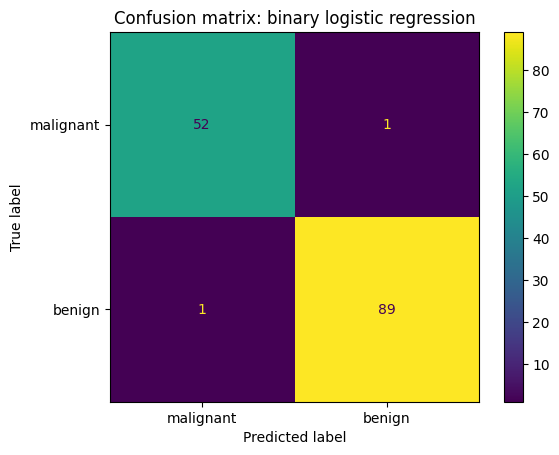

In [7]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("Confusion matrix: binary logistic regression")
plt.show()

## 11. ROC-кривая и ROC-AUC

Логистическая регрессия выдает не только метку класса, но и оценку вероятности:

$$
\hat{p} = P(y=1 \mid x).
$$

При изменении порога классификации $t$ меняются значения:

$$
TPR = \frac{TP}{TP + FN},
$$

$$
FPR = \frac{FP}{FP + TN}.
$$

Здесь $TPR$ — true positive rate, совпадающий с recall, а $FPR$ — false positive rate.

ROC-кривая строится в координатах:

$$
(FPR, TPR).
$$

Площадь под ROC-кривой называется ROC-AUC. Чем ближе ROC-AUC к 1, тем лучше модель разделяет объекты двух классов по вероятностным оценкам.

Значение

$$
ROC\text{-}AUC = 0.5
$$

соответствует случайному ранжированию объектов.

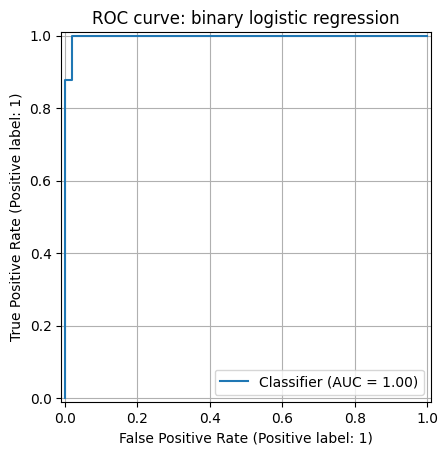

In [8]:
RocCurveDisplay.from_predictions(y_test, y_proba)

plt.title("ROC curve: binary logistic regression")
plt.grid(True)
plt.show()

## 12. Precision-Recall-кривая

Precision-Recall-кривая показывает зависимость precision и recall при изменении порога классификации.

Она строится в координатах:

$$
(Recall, Precision).
$$

Эта кривая особенно полезна при несбалансированных классах, когда положительный класс встречается редко.

Average Precision является агрегированной оценкой качества по Precision-Recall-кривой. В общем виде она может быть записана как взвешенная сумма precision при разных уровнях recall:

$$
AP =
\sum_{k}
(R_k - R_{k-1})P_k,
$$

где $P_k$ и $R_k$ — значения precision и recall на $k$-м шаге изменения порога.

Если положительный класс редкий, ROC-AUC может выглядеть достаточно высоким даже при большом количестве ложных срабатываний. Поэтому для редких положительных событий Precision-Recall-кривая часто более информативна.

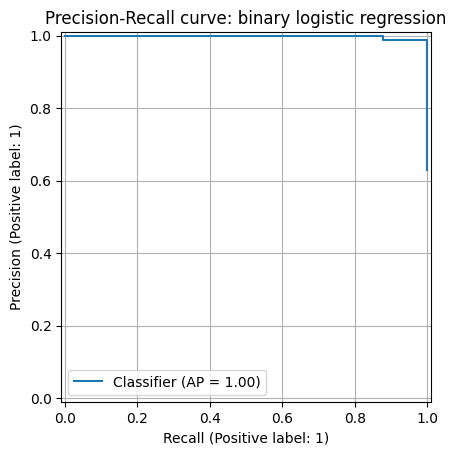

In [9]:
PrecisionRecallDisplay.from_predictions(y_test, y_proba)

plt.title("Precision-Recall curve: binary logistic regression")
plt.grid(True)
plt.show()

In [10]:
thresholds = np.linspace(0.1, 0.9, 9)

rows = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold),
        "recall": recall_score(y_test, y_pred_threshold),
        "f1": f1_score(y_test, y_pred_threshold),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(rows)
threshold_df

,threshold,precision,recall,f1,balanced_accuracy
0,0.1,0.927835,1.000000,0.962567,0.933962
1,0.2,0.957447,1.000000,0.978261,0.962264
2,0.3,0.967742,1.000000,0.983607,0.971698
3,0.4,0.988889,0.988889,0.988889,0.985010
4,0.5,0.988889,0.988889,0.988889,0.985010
5,0.6,0.988372,0.944444,0.965909,0.962788
6,0.7,0.988235,0.933333,0.960000,0.957233
7,0.8,0.988235,0.933333,0.960000,0.957233
8,0.9,1.000000,0.877778,0.934911,0.938889


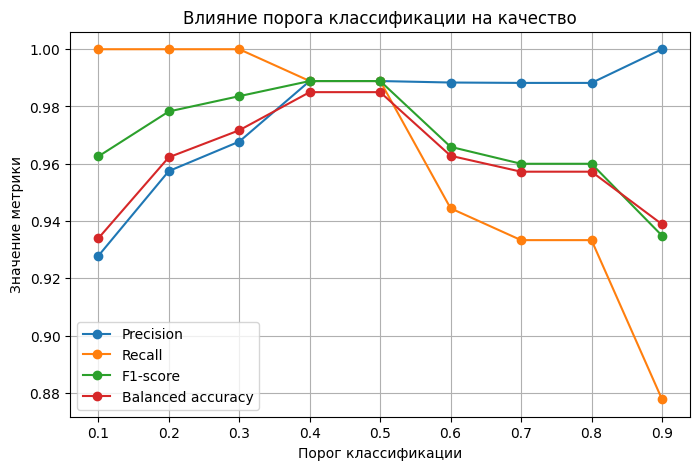

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1-score")
plt.plot(threshold_df["threshold"], threshold_df["balanced_accuracy"], marker="o", label="Balanced accuracy")

plt.xlabel("Порог классификации")
plt.ylabel("Значение метрики")
plt.title("Влияние порога классификации на качество")
plt.grid(True)
plt.legend()
plt.show()

## 14. Многоклассовая классификация

В многоклассовой классификации метка объекта принимает одно из $K$ возможных значений:

$$
y_i \in \{1, 2, \dots, K\}.
$$

Задача состоит в построении функции

$$
f: \mathbb{R}^m \rightarrow \{1, 2, \dots, K\}.
$$

В отличие от бинарного случая, модель должна оценивать вероятность принадлежности объекта каждому из $K$ классов:

$$
P(y = 1 \mid x),\ P(y = 2 \mid x),\ \dots,\ P(y = K \mid x).
$$

При этом вероятности должны удовлетворять условиям:

$$
P(y = k \mid x) \geq 0,
$$

$$
\sum_{k=1}^{K} P(y = k \mid x) = 1.
$$

## Сравнение подходов к многоклассовой классификации

В логистической регрессии для многоклассовой задачи можно использовать два основных подхода.

### Мультиномиальная логистическая регрессия

Модель оптимизирует единую функцию потерь сразу по всем классам:

$$
J(W,b) =
-\frac{1}{n}
\sum_{i=1}^{n}
\sum_{k=1}^{K}
y_{ik}
\log \hat{p}_{ik}.
$$

Вероятности классов связаны между собой через softmax:

$$
\sum_{k=1}^{K} \hat{p}_{ik} = 1.
$$

### One-vs-Rest

Обучается $K$ независимых бинарных классификаторов. Каждый классификатор отделяет один класс от всех остальных:

$$
k \ \text{против} \ \{1,\dots,K\} \setminus \{k\}.
$$

Итоговое решение:

$$
\hat{y} =
\arg\max_k h_k(x).
$$

Мультиномиальная модель обычно является более естественной вероятностной моделью для взаимоисключающих классов. One-vs-Rest удобен как универсальная стратегия сведения многоклассовой задачи к набору бинарных задач.

## 15. Мультиномиальная логистическая регрессия и softmax

Для каждого класса $k$ строится своя линейная функция:

$$
z_k = w_k^T x + b_k,
$$

где $w_k$ — вектор весов для класса $k$, а $b_k$ — свободный член для класса $k$.

Затем значения $z_1, z_2, \dots, z_K$ преобразуются в вероятности с помощью функции softmax:

$$
P(y = k \mid x) =
\frac{e^{z_k}}
{\sum_{j=1}^{K} e^{z_j}}.
$$

Или в развернутом виде:

$$
P(y = k \mid x) =
\frac{e^{w_k^T x + b_k}}
{\sum_{j=1}^{K} e^{w_j^T x + b_j}}.
$$

Предсказанный класс выбирается как класс с максимальной вероятностью:

$$
\hat{y} =
\arg\max_{k \in \{1,\dots,K\}}
P(y = k \mid x).
$$

Такая модель называется мультиномиальной логистической регрессией или softmax-регрессией.

## 16. Функция потерь для многоклассовой классификации

Для многоклассовой классификации используется категориальная кросс-энтропия.

Пусть истинная метка объекта $i$ закодирована в one-hot виде:

$$
y_{ik} =
\begin{cases}
1, & \text{если объект } i \text{ принадлежит классу } k, \\
0, & \text{иначе}.
\end{cases}
$$

Пусть модель оценивает вероятность класса $k$ для объекта $i$ как

$$
\hat{p}_{ik} = P(y_i = k \mid x_i).
$$

Тогда функция потерь имеет вид:

$$
J(W,b) =
-\frac{1}{n}
\sum_{i=1}^{n}
\sum_{k=1}^{K}
y_{ik}
\log \hat{p}_{ik}.
$$

Поскольку для каждого объекта только один элемент $y_{ik}$ равен 1, эта функция штрафует модель за малую вероятность истинного класса.

## 17. Регуляризация в многоклассовой логистической регрессии

В многоклассовой логистической регрессии каждому классу соответствует свой вектор весов:

$$
w_k = (w_{k1}, w_{k2}, \dots, w_{km})^T.
$$

Все веса можно объединить в матрицу параметров:

$$
W =
\begin{pmatrix}
w_1^T \\
w_2^T \\
\vdots \\
w_K^T
\end{pmatrix}.
$$

При L2-регуляризации штрафуется сумма квадратов всех весов:

$$
J_{L2}(W,b) =
J(W,b)
+
\lambda
\sum_{k=1}^{K}
\sum_{j=1}^{m}
w_{kj}^2.
$$

При L1-регуляризации используется сумма модулей:

$$
J_{L1}(W,b) =
J(W,b)
+
\lambda
\sum_{k=1}^{K}
\sum_{j=1}^{m}
|w_{kj}|.
$$

L1-регуляризация может приводить к разреженной матрице весов, то есть часть коэффициентов становится равной нулю. Это может быть полезно при большом числе признаков.

## 18. Стратегия One-vs-Rest

Один из способов свести многоклассовую классификацию к бинарной — стратегия One-vs-Rest.

Для каждого класса $k$ обучается отдельный бинарный классификатор:

$$
h_k(x): \mathbb{R}^m \rightarrow [0,1].
$$

Этот классификатор решает задачу:

$$
\text{класс } k
\quad \text{против} \quad
\text{всех остальных классов}.
$$

Для каждого класса создается бинарная целевая переменная:

$$
y_i^{(k)} =
\begin{cases}
1, & y_i = k, \\
0, & y_i \neq k.
\end{cases}
$$

После обучения $K$ бинарных моделей итоговый класс выбирается по максимальной оценке:

$$
\hat{y} =
\arg\max_{k \in \{1,\dots,K\}} h_k(x).
$$

Преимущество One-vs-Rest состоит в простоте реализации и интерпретации. Недостаток состоит в том, что вероятности разных бинарных моделей не всегда хорошо согласованы между собой.

## Данные для многоклассовой классификации: Digits

Для демонстрации многоклассовой логистической регрессии используется датасет `Digits`, встроенный в библиотеку `scikit-learn`.

Датасет загружается командой:

```
digits = load_digits()
```

Этот набор данных содержит изображения рукописных цифр от 0 до 9.

Целевая переменная принимает 10 возможных значений:

$$
y \in \{0,1,2,3,4,5,6,7,8,9\}.
$$

Каждый объект — это изображение цифры размером

$$
8 \times 8
$$

пикселей.

Изображение разворачивается в одномерный вектор длины

$$
64.
$$

Следовательно, объектно-признаковая матрица имеет вид:

$$
X \in \mathbb{R}^{n \times 64}.
$$

Всего в датасете:

$$
n = 1797
$$

объектов.

Каждый признак соответствует яркости одного пикселя изображения.

## Представление изображения как вектора признаков

В датасете `Digits` каждое изображение имеет размер:

$$
8 \times 8.
$$

То есть его можно представить как матрицу яркостей пикселей:

$$
A =
\begin{pmatrix}
a_{11} & a_{12} & \dots & a_{18} \\
a_{21} & a_{22} & \dots & a_{28} \\
\vdots & \vdots & \ddots & \vdots \\
a_{81} & a_{82} & \dots & a_{88}
\end{pmatrix}.
$$

Для подачи в логистическую регрессию эта матрица преобразуется в вектор:

$$
x =
(a_{11}, a_{12}, \dots, a_{18}, a_{21}, \dots, a_{88})^T.
$$

Длина такого вектора равна:

$$
8 \cdot 8 = 64.
$$

Поэтому каждый объект описывается 64 признаками:

$$
x_i \in \mathbb{R}^{64}.
$$

Модель не «видит» изображение как картинку в человеческом смысле. Для нее это просто набор чисел, каждое из которых соответствует яркости определенного пикселя.

In [12]:
digits = load_digits()

X_multi = digits.data
y_multi = digits.target

print("Размерность X:", X_multi.shape)
print("Количество классов:", len(np.unique(y_multi)))
print("Классы:", np.unique(y_multi))
print("Распределение классов:", Counter(y_multi))

df_multi = pd.DataFrame(X_multi)
df_multi["target"] = y_multi

df_multi.head()

Размерность X: (1797, 64)
Количество классов: 10
Классы: [0 1 2 3 4 5 6 7 8 9]
Распределение классов: Counter({np.int64(3): 183, np.int64(1): 182, np.int64(5): 182, np.int64(4): 181, np.int64(6): 181, np.int64(9): 180, np.int64(7): 179, np.int64(0): 178, np.int64(2): 177, np.int64(8): 174})


,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


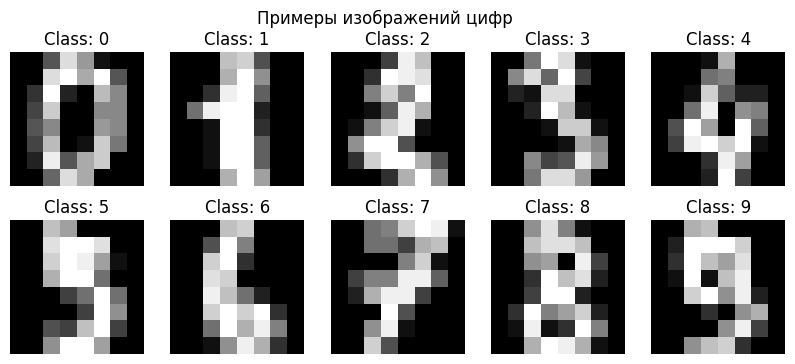

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, label in zip(axes.ravel(), digits.images[:10], y_multi[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Class: {label}")
    ax.axis("off")

plt.suptitle("Примеры изображений цифр")
plt.show()

In [15]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y_multi,
    test_size=0.25,
    random_state=42,
    stratify=y_multi
)

print("Обучающая выборка:", X_train_m.shape)
print("Тестовая выборка:", X_test_m.shape)
print("Распределение классов train:", Counter(y_train_m))
print("Распределение классов test:", Counter(y_test_m))

Обучающая выборка: (1347, 64)
Тестовая выборка: (450, 64)
Распределение классов train: Counter({np.int64(3): 137, np.int64(1): 136, np.int64(4): 136, np.int64(5): 136, np.int64(6): 136, np.int64(9): 135, np.int64(7): 134, np.int64(2): 133, np.int64(0): 133, np.int64(8): 131})
Распределение классов test: Counter({np.int64(1): 46, np.int64(5): 46, np.int64(3): 46, np.int64(0): 45, np.int64(9): 45, np.int64(6): 45, np.int64(7): 45, np.int64(4): 45, np.int64(2): 44, np.int64(8): 43})


## Какие варианты логистической регрессии сравниваются

В практической работе сравниваются несколько вариантов логистической регрессии для многоклассовой классификации.

Первый вариант — обычная многоклассовая логистическая регрессия:

```
LogisticRegression(solver="lbfgs")
```

Она обучает модель, которая напрямую решает задачу классификации на 10 классов.

Второй вариант — стратегия One-vs-Rest:

```
OneVsRestClassifier(LogisticRegression(...))
```

В этом случае многоклассовая задача разбивается на несколько бинарных задач. Для каждого класса строится отдельный классификатор: данный класс против всех остальных.

Третий вариант — логистическая регрессия с L1-регуляризацией:

```
LogisticRegression(penalty="l1", solver="saga")
```

Такой вариант может занулять часть коэффициентов модели и тем самым выполнять неявный отбор признаков.

Четвертый вариант — стохастическая логистическая регрессия:

```
SGDClassifier(loss="log_loss")
```

Она обучается с помощью стохастического градиентного спуска и может быть полезна для больших датасетов.

Сравнение этих моделей показывает, что одна и та же идея логистической регрессии может реализовываться разными алгоритмическими способами.

## Что означает параметр solver

Параметр `solver` задает численный алгоритм оптимизации, который используется для поиска коэффициентов логистической регрессии.

В коде используются, например:

```
solver="lbfgs"
```

и

```
solver="saga"
```

Алгоритм `lbfgs` хорошо подходит для стандартной L2-регуляризованной логистической регрессии и часто используется как надежный базовый вариант.

Алгоритм `saga` поддерживает разные типы регуляризации, включая L1-регуляризацию. Поэтому он используется в модели:

```
LogisticRegression(penalty="l1", solver="saga")
```

Выбор solver не меняет математическую постановку задачи классификации, но влияет на то, каким численным методом минимизируется функция потерь.

В общем виде обучение модели можно записать как задачу оптимизации:

$$
\hat{w}, \hat{b}
=
\arg\min_{w,b} J(w,b).
$$

Solver отвечает именно за практический способ решения этой оптимизационной задачи.

## Основные алгоритмы оптимизации в LogisticRegression

В `scikit-learn` для логистической регрессии доступны разные значения параметра `solver`.

Каждый solver — это конкретный численный метод минимизации функции потерь.

### `lbfgs`

`lbfgs` — это вариант метода BFGS с ограниченным использованием памяти.

Полное название:

$$
\text{Limited-memory Broyden--Fletcher--Goldfarb--Shanno algorithm}.
$$

По-русски его можно называть:

**L-BFGS**, или **квазиньютоновский метод L-BFGS с ограниченной памятью**.

Метод относится к квазиньютоновским методам оптимизации. Он использует информацию о градиенте функции потерь и приближенно учитывает информацию о кривизне функции.

В учебных задачах `lbfgs` часто является хорошим базовым выбором.

Обычно его используют для:

- L2-регуляризации;
- задач бинарной классификации;
- задач многоклассовой классификации;
- данных среднего размера.

В примере:

```
LogisticRegression(solver="lbfgs")
```

означает, что параметры логистической регрессии подбираются методом L-BFGS.

### `liblinear`

`liblinear` — это алгоритм из библиотеки LIBLINEAR, предназначенной для линейных моделей.

По-русски можно сказать:

**решатель LIBLINEAR для линейных моделей**.

Он хорошо подходит для небольших датасетов и бинарной классификации.

Особенность `liblinear` состоит в том, что он изначально не является полноценным мультиномиальным решателем. Для многоклассовой классификации обычно используется схема One-vs-Rest.

Этот solver поддерживает L1- и L2-регуляризацию, но имеет ограничения по сравнению с более современными методами.

### `newton-cg`

`newton-cg` — это ньютоновский метод с использованием сопряженных градиентов.

По-русски:

**метод Ньютона с сопряженными градиентами**.

Методы Ньютона используют не только градиент функции потерь, но и информацию о второй производной, то есть о кривизне функции.

В общем виде шаг ньютоновского метода можно записать как:

$$
\theta_{t+1}
=
\theta_t
-
H^{-1} \nabla J(\theta_t),
$$

где:

$$
\theta
$$

— вектор всех параметров модели,

$$
\nabla J(\theta_t)
$$

— градиент функции потерь,

$$
H
$$

— матрица вторых производных, или гессиан.

Метод `newton-cg` не обращает гессиан напрямую, а использует сопряженные градиенты для приближенного решения соответствующей системы линейных уравнений.

### `newton-cholesky`

`newton-cholesky` — это ньютоновский метод, в котором используется разложение Холецкого.

По-русски:

**ньютоновский метод с разложением Холецкого**.

Он также использует информацию о гессиане, но решает возникающие системы линейных уравнений через разложение Холецкого.

Этот метод может быть эффективен, когда число объектов существенно больше числа признаков. Однако он может требовать много памяти, поскольку работа с гессианом становится затратной при большом числе признаков или классов.

### `sag`

`sag` означает Stochastic Average Gradient.

По-русски:

**метод стохастического усредненного градиента**.

Он относится к стохастическим методам оптимизации. Такие методы не обязательно используют всю выборку на каждом шаге, что делает их полезными для больших наборов данных.

Обычный градиентный спуск на каждом шаге использует градиент по всей обучающей выборке:

$$
\nabla J(w)
=
\frac{1}{n}
\sum_{i=1}^{n}
\nabla J_i(w).
$$

Стохастические методы используют отдельные объекты или небольшие подвыборки, что уменьшает стоимость одного шага оптимизации.

Метод `sag` хранит и усредняет информацию о градиентах по объектам, что позволяет ускорить сходимость по сравнению с обычным стохастическим градиентным спуском.

Важно: `sag` чувствителен к масштабу признаков, поэтому перед его использованием особенно важно выполнять стандартизацию.

### `saga`

`saga` — это развитие метода SAG.

По-русски его можно называть:

**метод SAGA**, или **стохастический метод оптимизации SAGA**.

Он также относится к стохастическим методам, но имеет важное преимущество: поддерживает L1-регуляризацию.

Именно поэтому в примере для L1-регуляризованной логистической регрессии используется:

```
LogisticRegression(
    penalty="l1",
    solver="saga"
)
```

L1-регуляризация добавляет к функции потерь штраф:

$$
\lambda \sum_{j=1}^{m} |w_j|.
$$

Не все алгоритмы оптимизации удобно работают с таким штрафом, потому что функция $|w_j|$ не является дифференцируемой в нуле. Метод `saga` подходит для такой задачи.

## Как выбирать solver на практике

Выбор `solver` зависит от размера данных, типа регуляризации и постановки задачи.

Для большинства учебных и прикладных задач хорошим базовым вариантом является:

```
solver="lbfgs"
```

Он устойчиво работает для L2-регуляризации и поддерживает многоклассовую логистическую регрессию.

Если нужна L1-регуляризация, следует использовать:

```
solver="saga"
```

или в некоторых случаях:

```
solver="liblinear"
```

Однако для многоклассовых задач с L1-регуляризацией чаще удобнее использовать `saga`.

Если данных много, можно рассмотреть стохастические методы:

```
solver="sag"
```

или

```
solver="saga"
```

Но для них особенно важно масштабировать признаки.

Если датасет небольшой и задача бинарная, можно использовать:

```
solver="liblinear"
```

Для задач, где число объектов значительно больше числа признаков, может быть полезен:

```
solver="newton-cholesky"
```

Однако в учебной практике обычно достаточно понимать три основных варианта:

1. `lbfgs` — стандартный надежный вариант;
2. `saga` — вариант для L1-регуляризации и больших данных;
3. `liblinear` — вариант для небольших бинарных задач.

Главное правило: solver должен быть совместим с выбранной регуляризацией и типом задачи.

## Совместимость solver и регуляризации

Не каждый алгоритм оптимизации поддерживает любой тип регуляризации.

В логистической регрессии часто используются следующие типы регуляризации:

$$
L1: \quad \lambda \sum_{j=1}^{m} |w_j|,
$$

$$
L2: \quad \lambda \sum_{j=1}^{m} w_j^2.
$$

L2-регуляризация является гладкой, поэтому с ней хорошо работают многие методы оптимизации.

L1-регуляризация негладкая в нуле, поэтому ее поддерживают не все solver.

Упрощенно можно ориентироваться на следующую схему:

| Solver | Русское название | L2 | L1 | Многоклассовая softmax-модель |
|---|---|---:|---:|---:|
| `lbfgs` | квазиньютоновский метод L-BFGS | да | нет | да |
| `liblinear` | решатель LIBLINEAR для линейных моделей | да | да | нет, обычно One-vs-Rest |
| `newton-cg` | метод Ньютона с сопряженными градиентами | да | нет | да |
| `newton-cholesky` | метод Ньютона с разложением Холецкого | да | нет | да |
| `sag` | метод стохастического усредненного градиента | да | нет | да |
| `saga` | стохастический метод SAGA | да | да | да |

Поэтому если в коде указано:

```
penalty="l1"
```

то нельзя произвольно выбрать любой solver. Нужно использовать solver, который поддерживает L1-регуляризацию, например:

```
solver="saga"
```

Если используется стандартная L2-регуляризация, то хорошим базовым выбором является:

```
solver="lbfgs"
```

In [16]:
multinomial_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        solver="lbfgs",
        C=1.0,
        max_iter=2000,
        random_state=42
    ))
])

multinomial_model.fit(X_train_m, y_train_m)

y_pred_multinomial = multinomial_model.predict(X_test_m)
y_proba_multinomial = multinomial_model.predict_proba(X_test_m)

In [17]:
ovr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ovr", OneVsRestClassifier(
        LogisticRegression(
            solver="lbfgs",
            C=1.0,
            max_iter=2000,
            random_state=42
        )
    ))
])

ovr_model.fit(X_train_m, y_train_m)

y_pred_ovr = ovr_model.predict(X_test_m)
y_proba_ovr = ovr_model.predict_proba(X_test_m)

## Что означает параметр C

Параметр `C` управляет силой регуляризации в логистической регрессии.

В коде встречается, например:

```
C=1.0
```

или

```
C=0.5
```

В `scikit-learn` параметр `C` обратно пропорционален коэффициенту регуляризации:

$$
C \sim \frac{1}{\lambda}.
$$

Это означает:

$$
C \downarrow
\quad \Rightarrow \quad
\lambda \uparrow,
$$

то есть при уменьшении `C` регуляризация становится сильнее.

И наоборот:

$$
C \uparrow
\quad \Rightarrow \quad
\lambda \downarrow,
$$

то есть при увеличении `C` регуляризация становится слабее.

Слишком слабая регуляризация может привести к переобучению, а слишком сильная — к недообучению.

In [18]:
l1_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l1",
        solver="saga",
        C=0.5,
        max_iter=5000,
        random_state=42
    ))
])

l1_model.fit(X_train_m, y_train_m)

y_pred_l1 = l1_model.predict(X_test_m)
y_proba_l1 = l1_model.predict_proba(X_test_m)

In [19]:
sgd_log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("sgd", SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=0.0001,
        max_iter=2000,
        random_state=42
    ))
])

sgd_log_model.fit(X_train_m, y_train_m)

y_pred_sgd = sgd_log_model.predict(X_test_m)
y_proba_sgd = sgd_log_model.predict_proba(X_test_m)

## 20. Матрица ошибок для многоклассовой классификации

Для $K$ классов матрица ошибок имеет размер

$$
K \times K.
$$

Элемент матрицы

$$
C_{ij}
$$

показывает, сколько объектов истинного класса $i$ были отнесены моделью к классу $j$.

Диагональные элементы

$$
C_{ii}
$$

соответствуют правильным классификациям.

Внедиагональные элементы

$$
C_{ij}, \quad i \neq j
$$

соответствуют ошибкам классификации.

Матрица ошибок позволяет понять, какие классы модель чаще всего путает между собой.

## 21. Усреднение метрик в многоклассовой классификации

В многоклассовой классификации precision, recall и F1-score можно вычислять отдельно для каждого класса, а затем усреднять.

### Macro-усреднение

Сначала метрика вычисляется отдельно для каждого класса, затем берется обычное среднее:

$$
Metric_{macro}
=
\frac{1}{K}
\sum_{k=1}^{K}
Metric_k.
$$

Macro-усреднение одинаково учитывает все классы, независимо от их размера.

### Weighted-усреднение

При weighted-усреднении вклад каждого класса пропорционален числу объектов этого класса:

$$
Metric_{weighted}
=
\sum_{k=1}^{K}
\frac{n_k}{n}
Metric_k,
$$

где $n_k$ — число объектов класса $k$, а $n$ — общее число объектов.

Weighted-усреднение сильнее зависит от качества на крупных классах.

### Micro-усреднение

При micro-усреднении сначала суммируются значения $TP$, $FP$ и $FN$ по всем классам, а затем вычисляется метрика:

$$
Precision_{micro}
=
\frac{\sum_{k=1}^{K} TP_k}
{\sum_{k=1}^{K} TP_k + \sum_{k=1}^{K} FP_k}.
$$

$$
Recall_{micro}
=
\frac{\sum_{k=1}^{K} TP_k}
{\sum_{k=1}^{K} TP_k + \sum_{k=1}^{K} FN_k}.
$$

Для задачи однозначной многоклассовой классификации micro-precision, micro-recall и micro-F1 часто совпадают с accuracy.

## 22. Метрики качества по отдельным классам

Для каждого класса $k$ можно рассматривать его как положительный класс, а все остальные классы — как отрицательный класс. Тогда вычисляются значения:

$$
Precision_k =
\frac{TP_k}{TP_k + FP_k},
$$

$$
Recall_k =
\frac{TP_k}{TP_k + FN_k},
$$

$$
F_{1,k} =
2 \cdot
\frac{Precision_k \cdot Recall_k}
{Precision_k + Recall_k}.
$$

Такой подход позволяет определить, для каких классов модель работает хорошо, а для каких — плохо.

Это особенно важно при дисбалансе классов: общая accuracy может быть высокой, но качество распознавания редких классов может быть неудовлетворительным.

In [20]:
def evaluate_multiclass_model(model_name, y_true, y_pred, y_proba):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro"),
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted"),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "log_loss": log_loss(y_true, y_proba)
    }

## Что означает log_loss

Метрика `log_loss` оценивает качество вероятностных предсказаний модели.

В отличие от accuracy, она учитывает не только итоговый выбранный класс, но и то, насколько уверенно модель сделала прогноз.

Для многоклассовой классификации log loss вычисляется как:

$$
LogLoss =
-\frac{1}{n}
\sum_{i=1}^{n}
\sum_{k=1}^{K}
y_{ik}
\log \hat{p}_{ik}.
$$

Если модель присваивает истинному классу высокую вероятность, вклад объекта в log loss мал.

Если модель присваивает истинному классу низкую вероятность, вклад объекта в log loss велик.

Например, если истинный класс объекта — $k$, и модель оценила его вероятность как

$$
\hat{p}_{ik} = 0.99,
$$

то штраф будет малым:

$$
-\log(0.99).
$$

Если же модель присвоила истинному классу вероятность

$$
\hat{p}_{ik} = 0.01,
$$

то штраф будет большим:

$$
-\log(0.01).
$$

Таким образом, log loss особенно полезна, когда важны не только метки классов, но и корректность вероятностных оценок.

In [21]:
results = []

results.append(evaluate_multiclass_model(
    "Multinomial logistic regression",
    y_test_m,
    y_pred_multinomial,
    y_proba_multinomial
))

results.append(evaluate_multiclass_model(
    "One-vs-Rest logistic regression",
    y_test_m,
    y_pred_ovr,
    y_proba_ovr
))

results.append(evaluate_multiclass_model(
    "L1 logistic regression",
    y_test_m,
    y_pred_l1,
    y_proba_l1
))

results.append(evaluate_multiclass_model(
    "SGD logistic regression",
    y_test_m,
    y_pred_sgd,
    y_proba_sgd
))

results_df = pd.DataFrame(results)
results_df

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,log_loss
0,Multinomial logistic regression,0.977778,0.977661,0.977767,0.977661,0.977641,0.978026,0.977778,0.977829,0.103485
1,One-vs-Rest logistic regression,0.973333,0.973368,0.973499,0.973368,0.973197,0.973605,0.973333,0.973232,0.146357
2,L1 logistic regression,0.968889,0.968717,0.968715,0.968717,0.968550,0.969072,0.968889,0.968815,0.138711
3,SGD logistic regression,0.937778,0.938142,0.939210,0.938142,0.937025,0.939925,0.937778,0.937200,1.126031


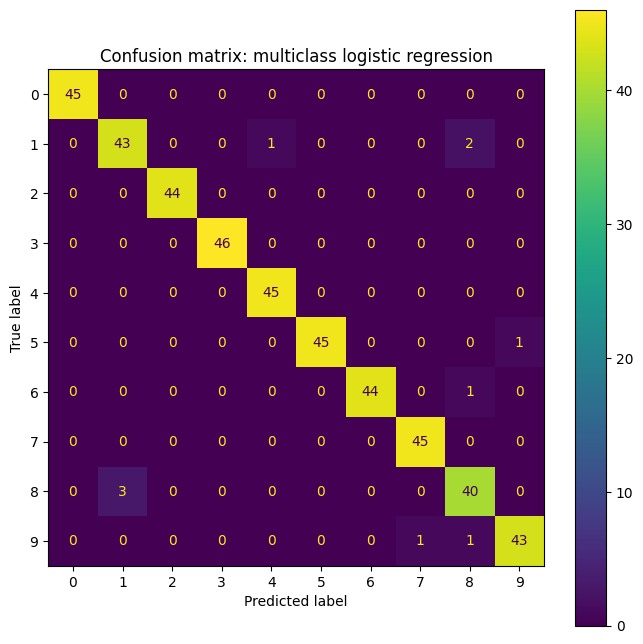

In [22]:
cm_multi = confusion_matrix(y_test_m, y_pred_multinomial)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_multi,
    display_labels=digits.target_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion matrix: multiclass logistic regression")
plt.show()

In [23]:
print(classification_report(
    y_test_m,
    y_pred_multinomial,
    target_names=[str(label) for label in digits.target_names]
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.93      0.93      0.93        46
           2       1.00      1.00      1.00        44
           3       1.00      1.00      1.00        46
           4       0.98      1.00      0.99        45
           5       1.00      0.98      0.99        46
           6       1.00      0.98      0.99        45
           7       0.98      1.00      0.99        45
           8       0.91      0.93      0.92        43
           9       0.98      0.96      0.97        45

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



## 23. Дисбаланс классов

Дисбаланс классов возникает, когда объекты разных классов представлены в выборке неравномерно.

Например, для бинарной классификации может быть ситуация:

$$
P(y=0) \gg P(y=1).
$$

В этом случае модель может получить высокую accuracy, почти всегда предсказывая мажоритарный класс.

Например, если 95% объектов относятся к классу 0, то классификатор, который всегда предсказывает 0, будет иметь:

$$
Accuracy = 0.95.
$$

Однако такая модель полностью бесполезна для обнаружения класса 1.

Поэтому при дисбалансе классов следует анализировать не только accuracy, но и:

$$
Precision, \quad Recall, \quad F_1, \quad Balanced\ Accuracy,
$$

а также матрицу ошибок и метрики по каждому классу.

## 24. Учет дисбаланса через веса классов

Один из способов учета дисбаланса — назначить объектам редких классов больший вес в функции потерь.

Обычная функция потерь для бинарной классификации:

$$
J(w,b) =
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log \hat{p}_i
+
(1-y_i)\log(1-\hat{p}_i)
\right].
$$

С учетом весов классов:

$$
J(w,b) =
-\frac{1}{n}
\sum_{i=1}^{n}
\alpha_{y_i}
\left[
y_i \log \hat{p}_i
+
(1-y_i)\log(1-\hat{p}_i)
\right],
$$

где $\alpha_{y_i}$ — вес класса, к которому принадлежит объект $i$.

Для многоклассовой классификации взвешенная кросс-энтропия имеет вид:

$$
J(W,b) =
-\frac{1}{n}
\sum_{i=1}^{n}
\sum_{k=1}^{K}
\alpha_k y_{ik}
\log \hat{p}_{ik}.
$$

В `scikit-learn` параметр

```python
class_weight="balanced"
```

автоматически задает веса классов обратно пропорционально их частотам.

## Как в примере создается дисбаланс классов

Для демонстрации проблемы дисбаланса классов в практической работе искусственно изменяется датасет `Digits`.

Исходный датасет содержит изображения цифр от 0 до 9. Изначально классы представлены относительно равномерно.

Далее для классов

$$
0, 1, 2
$$

оставляется только часть объектов:

```
if cls in [0, 1, 2]:
    n_samples = int(0.2 * len(cls_indices))
else:
    n_samples = len(cls_indices)
```

Это означает, что классы 0, 1 и 2 становятся редкими, а остальные классы остаются представленными полностью.

После этого формируется новая выборка:

$$
X_{imbalanced}, y_{imbalanced}.
$$

Таким образом, создается ситуация, когда одни классы представлены значительно хуже других.

Это нужно для того, чтобы показать, почему обычная accuracy может быть недостаточной и зачем используются `balanced_accuracy`, `macro F1-score` и `class_weight="balanced"`.

In [24]:
rng = np.random.default_rng(42)

selected_indices = []

for cls in np.unique(y_multi):
    cls_indices = np.where(y_multi == cls)[0]

    if cls in [0, 1, 2]:
        # Оставим для некоторых классов только малую часть объектов
        n_samples = int(0.2 * len(cls_indices))
    else:
        n_samples = len(cls_indices)

    chosen_indices = rng.choice(cls_indices, size=n_samples, replace=False)
    selected_indices.extend(chosen_indices)

selected_indices = np.array(selected_indices)

X_imbalanced = X_multi[selected_indices]
y_imbalanced = y_multi[selected_indices]

print("Исходное распределение классов:")
print(Counter(y_multi))

print("\nРаспределение классов после внесения дисбаланса:")
print(Counter(y_imbalanced))

Исходное распределение классов:
Counter({np.int64(3): 183, np.int64(1): 182, np.int64(5): 182, np.int64(4): 181, np.int64(6): 181, np.int64(9): 180, np.int64(7): 179, np.int64(0): 178, np.int64(2): 177, np.int64(8): 174})

Распределение классов после внесения дисбаланса:
Counter({np.int64(3): 183, np.int64(5): 182, np.int64(4): 181, np.int64(6): 181, np.int64(9): 180, np.int64(7): 179, np.int64(8): 174, np.int64(1): 36, np.int64(0): 35, np.int64(2): 35})


In [25]:
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_imbalanced,
    y_imbalanced,
    test_size=0.25,
    random_state=42,
    stratify=y_imbalanced
)

print("Train:", Counter(y_train_i))
print("Test:", Counter(y_test_i))

Train: Counter({np.int64(3): 137, np.int64(5): 136, np.int64(6): 136, np.int64(4): 136, np.int64(9): 135, np.int64(7): 134, np.int64(8): 131, np.int64(1): 27, np.int64(2): 26, np.int64(0): 26})
Test: Counter({np.int64(5): 46, np.int64(3): 46, np.int64(6): 45, np.int64(4): 45, np.int64(9): 45, np.int64(7): 45, np.int64(8): 43, np.int64(0): 9, np.int64(2): 9, np.int64(1): 9})


In [26]:
imbalanced_baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        solver="lbfgs",
        C=1.0,
        max_iter=2000,
        random_state=42
    ))
])

imbalanced_baseline_model.fit(X_train_i, y_train_i)

y_pred_i_baseline = imbalanced_baseline_model.predict(X_test_i)
y_proba_i_baseline = imbalanced_baseline_model.predict_proba(X_test_i)

In [27]:
balanced_weight_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        solver="lbfgs",
        C=1.0,
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

balanced_weight_model.fit(X_train_i, y_train_i)

y_pred_i_balanced = balanced_weight_model.predict(X_test_i)
y_proba_i_balanced = balanced_weight_model.predict_proba(X_test_i)

In [28]:
imbalance_results = []

imbalance_results.append(evaluate_multiclass_model(
    "Without class weights",
    y_test_i,
    y_pred_i_baseline,
    y_proba_i_baseline
))

imbalance_results.append(evaluate_multiclass_model(
    "With class_weight='balanced'",
    y_test_i,
    y_pred_i_balanced,
    y_proba_i_balanced
))

imbalance_results_df = pd.DataFrame(imbalance_results)
imbalance_results_df

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,log_loss
0,Without class weights,0.959064,0.924486,0.957937,0.924486,0.938198,0.960300,0.959064,0.958445,0.136253
1,With class_weight='balanced',0.959064,0.933272,0.951630,0.933272,0.940803,0.960261,0.959064,0.958958,0.125953


In [29]:
print(classification_report(
    y_test_i,
    y_pred_i_baseline,
    target_names=[str(label) for label in np.unique(y_imbalanced)]
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.86      0.67      0.75         9
           2       1.00      0.78      0.88         9
           3       1.00      0.93      0.97        46
           4       0.98      0.98      0.98        45
           5       0.96      1.00      0.98        46
           6       0.98      0.98      0.98        45
           7       0.98      0.98      0.98        45
           8       0.88      0.98      0.92        43
           9       0.96      0.96      0.96        45

    accuracy                           0.96       342
   macro avg       0.96      0.92      0.94       342
weighted avg       0.96      0.96      0.96       342



In [30]:
print(classification_report(
    y_test_i,
    y_pred_i_balanced,
    target_names=[str(label) for label in np.unique(y_imbalanced)]
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.78      0.78      0.78         9
           2       1.00      0.78      0.88         9
           3       1.00      0.93      0.97        46
           4       0.98      0.98      0.98        45
           5       0.96      1.00      0.98        46
           6       0.98      0.98      0.98        45
           7       0.98      0.98      0.98        45
           8       0.89      0.95      0.92        43
           9       0.96      0.96      0.96        45

    accuracy                           0.96       342
   macro avg       0.95      0.93      0.94       342
weighted avg       0.96      0.96      0.96       342



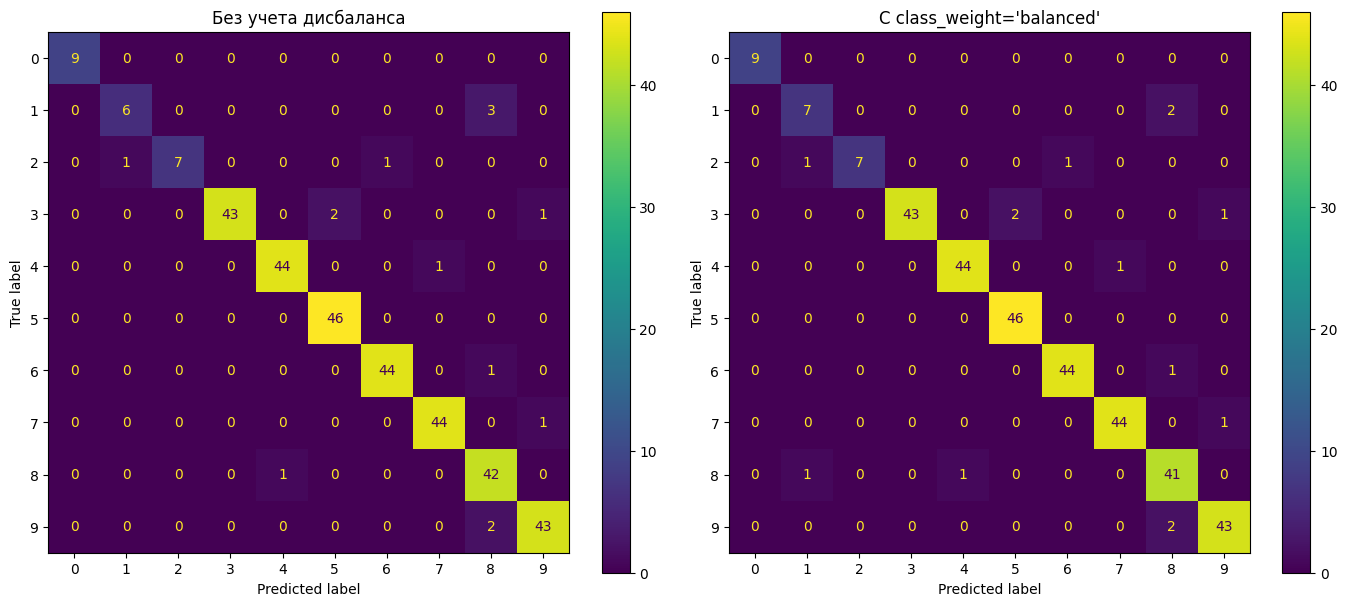

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_baseline = confusion_matrix(y_test_i, y_pred_i_baseline)
cm_balanced = confusion_matrix(y_test_i, y_pred_i_balanced)

disp_baseline = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=np.unique(y_imbalanced)
)

disp_balanced = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=np.unique(y_imbalanced)
)

disp_baseline.plot(ax=axes[0], values_format="d")
axes[0].set_title("Без учета дисбаланса")

disp_balanced.plot(ax=axes[1], values_format="d")
axes[1].set_title("С class_weight='balanced'")

plt.tight_layout()
plt.show()